# Two Steps MultiFidelity Neural Network

Code to show the performance of the Neural Network when dealing with different LF datasets 

In [1]:
######### LIBRARIES ############
import keras.backend as K
from keras.regularizers import l2
from hyperopt import STATUS_OK, tpe, Trials, hp, fmin
from hyperopt.pyll.stochastic import sample
from sklearn.model_selection import KFold
from keras.models import save_model
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import cm
from matplotlib.ticker import LinearLocator, FormatStrFormatter
from keras.optimizers import Adam, Nadam, Adamax
from Multifidelity_support import getModel, kCrossVal, transfBestparam, import_data, normalization, add_noise, MultiFidelity
from time import perf_counter
import pandas
import pickle
import os
import keras
import tensorflow as tf


In [2]:
# reproducibility
seed = 42
np.random.seed(seed)
keras.utils.set_random_seed(seed)
tf.random.set_seed(seed)

## Data Preparation

In [3]:
# import of the discretization and diffusion values
Discretizations= np.loadtxt(
    "../DATA/Discretizations.txt"
).astype(
    int
)[::-1]

diffusion= np.loadtxt(
    "../DATA/diffusion.txt"
).astype(
    int
)

In [4]:
file_path_HF = "../DATA/reaction_diffusion_HF.mat"
(reaction_HF_test, U_HF_test) = import_data(file_path_HF)

reaction_HF_test = normalization(reaction_HF_test)
U_HF_test = U_HF_test[:, -1, 44,44]
U_HF_test=normalization(U_HF_test)

reaction_HF_test_original=np.c_[reaction_HF_test, np.abs(np.sin(5*np.pi*reaction_HF_test[:, 0]-5*np.pi/6))]
U_HF_test_original=U_HF_test

In [5]:
noise_stddev1=[0.01,0.005,0.02,0.005]
noise_stddev2=[0.005,0.003,0.01,0.003]

# noise_stddev2 = 0.01       # value?
# noise2 = np.random.normal(0, noise_stddev2, U_HF_test.shape[0])
# noise_stddev3 = 0.005       # value?
# noise3 = np.random.normal(0, noise_stddev3, U_HF_test.shape[0])
# U_HF_noise2 = U_HF_test + noise2
# U_HF_noise3 = U_HF_test + noise3

# noise_stddev4 = 0.02       # value?
# noise4 = np.random.normal(0, noise_stddev4, U_HF_test.shape[0])
# noise_stddev5 = 0.005       # value?
# noise5 = np.random.normal(0, noise_stddev5, U_HF_test.shape[0])
# U_HF_noise4 = U_HF_test + noise4
# U_HF_noise5 = U_HF_test + noise5



# U_HF_test = np.concatenate((U_HF_test, U_HF_noise2,U_HF_noise3,U_HF_noise4,U_HF_noise5),axis=0)


# noise_stddev2 = 0.005       # value?
# noise2 = np.random.normal(0, noise_stddev2, reaction_HF_test.shape[0])
# noise_stddev3 = 0.003       # value?
# noise3 = np.random.normal(0, noise_stddev3, reaction_HF_test.shape[0])
# reaction_HF_noise2 = reaction_HF_test + noise2
# reaction_HF_noise3 = reaction_HF_test + noise3

# noise_stddev4 = 0.01       # value?
# noise4 = np.random.normal(0, noise_stddev4, reaction_HF_test.shape)
# noise_stddev5 = 0.003       # value?
# noise5 = np.random.normal(0, noise_stddev5, reaction_HF_test.shape)
# reaction_HF_noise4 = reaction_HF_test + noise4
# reaction_HF_noise5 = reaction_HF_test + noise5

# reaction_HF_test = np.concatenate((reaction_HF_test, reaction_HF_noise2,reaction_HF_noise3,reaction_HF_noise4,reaction_HF_noise5))
(U_HF_test,reaction_HF_test)=add_noise(noise_stddev1,noise_stddev2,reaction_HF_test,U_HF_test)

reaction_HF_test=np.c_[reaction_HF_test, np.abs(np.sin(5*np.pi*reaction_HF_test[:, 0]-5*np.pi/6))]

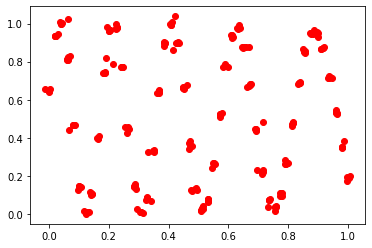

In [6]:

plt.plot(reaction_HF_test[:,0], U_HF_test, "ro", linewidth=1, label="HF model with noise")

plt.show()

In [7]:
print(reaction_HF_test.shape)
print(U_HF_test.shape)

n_HF = np.array([100])
Nlf = np.array([200])

batch_size=[200,100]


(250, 2)
(250,)


In [8]:
U_LF_list = []
U_HF_list = []

Nepo=[7000,2000]

# NepoLF = 7000  # number of epochs for first NN: NN_LF
# NepoHF = 8000  # number of epochs for second NN: NN_HF

r2_HF_df = pandas.DataFrame(columns=['Discretization','diffusion','R2'])  # dataframe which stores HF R^2
r2_LF_df = pandas.DataFrame(columns=['Discretization','diffusion','R2'])  # dataframe which stores LF R^2
mse_HF_df = pandas.DataFrame(columns=['Discretization','diffusion','MSE'])  # dataframe which stores HF MSE
mse_LF_df = pandas.DataFrame(columns=['Discretization','diffusion','MSE'])  # dataframe which stores LF MSE



## Neural Network
Cycle on the Discretization and the value of the diffusion 

********************  # Nb. nodes = 46  ********************
********************  # Diff: = 0  ********************
********************  # NHF: = 100  ********************
********************  # NLF: = 200  ********************


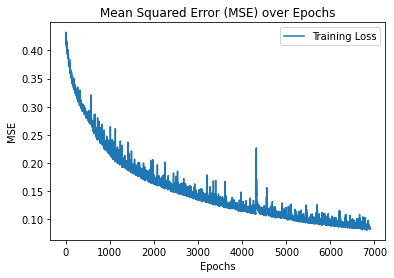

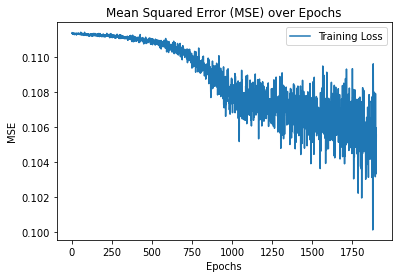

low fidelity NN
Test MSE: 0.006434266424512856
R^2: 0.9483532342394667
Final model
Test MSE: 0.1103227590688841
R^2: 0.02540687937149433


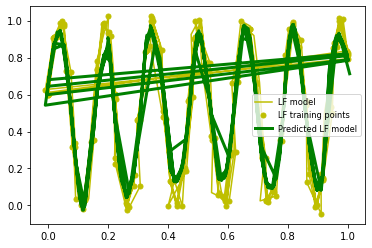

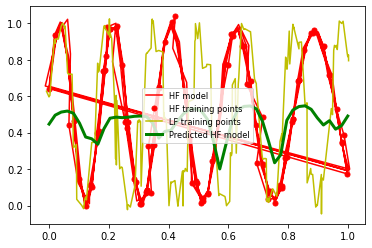

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_6260\1919213603.py:174: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df = r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_6260\1919213603.py:176: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df = r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_6260\1919213603.py:178: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df = mse_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_6260\1919213603.py:180: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_HF_df = mse_HF_df.app

SAVING...
********************  # Nb. nodes = 46  ********************
********************  # Diff: = 5  ********************
********************  # NHF: = 100  ********************
********************  # NLF: = 200  ********************


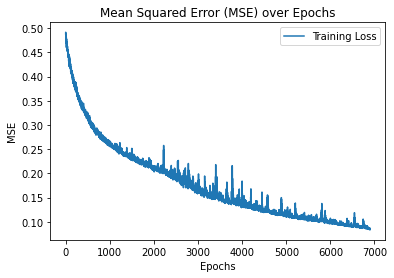

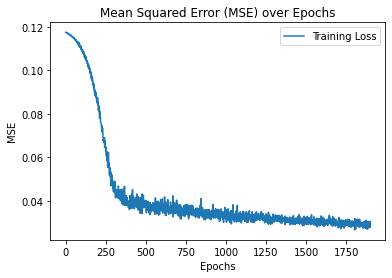

low fidelity NN
Test MSE: 0.001979187800776259
R^2: 0.9826023243992233
Final model
Test MSE: 0.02368024944243638
R^2: 0.7908082756799482


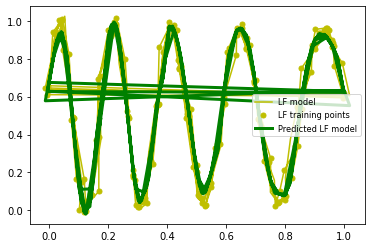

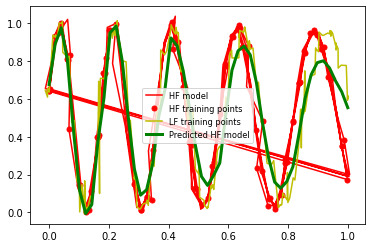

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_6260\1919213603.py:174: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df = r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_6260\1919213603.py:176: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df = r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_6260\1919213603.py:178: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df = mse_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_6260\1919213603.py:180: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_HF_df = mse_HF_df.app

SAVING...
********************  # Nb. nodes = 46  ********************
********************  # Diff: = 75  ********************
********************  # NHF: = 100  ********************
********************  # NLF: = 200  ********************


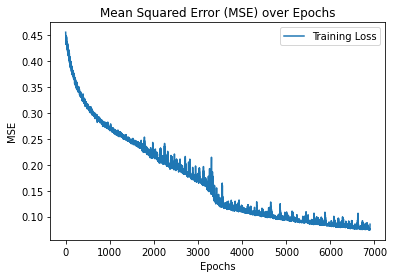

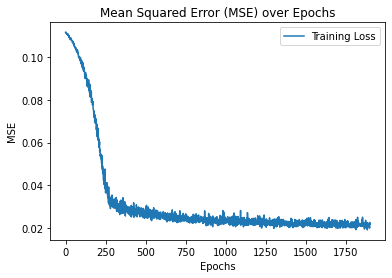

low fidelity NN
Test MSE: 0.01001209740744011
R^2: 0.9149991487397812
Final model
Test MSE: 0.013476945774168154
R^2: 0.880944432957966


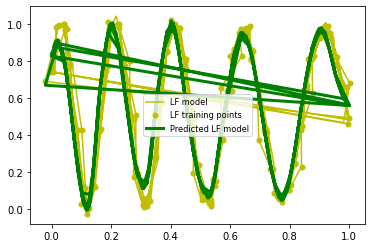

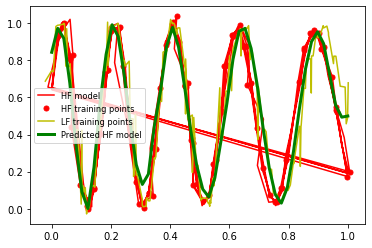

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_6260\1919213603.py:174: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df = r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_6260\1919213603.py:176: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df = r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_6260\1919213603.py:178: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df = mse_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_6260\1919213603.py:180: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_HF_df = mse_HF_df.app

SAVING...
********************  # Nb. nodes = 46  ********************
********************  # Diff: = 1  ********************
********************  # NHF: = 100  ********************
********************  # NLF: = 200  ********************


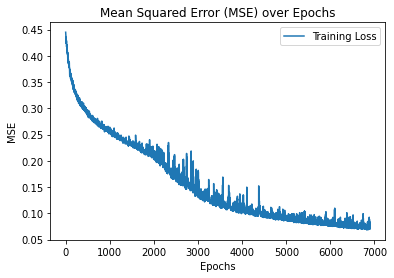

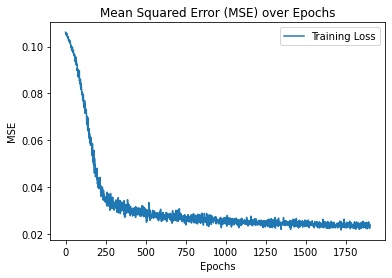

low fidelity NN
Test MSE: 0.004548107073434494
R^2: 0.9607091765590838
Final model
Test MSE: 0.015461643438713283
R^2: 0.8634115802019412


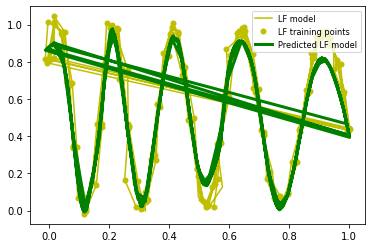

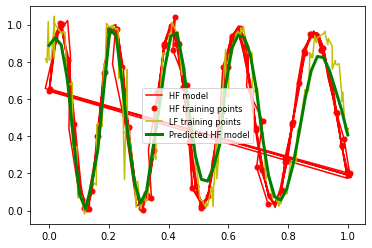

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_6260\1919213603.py:174: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df = r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_6260\1919213603.py:176: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df = r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_6260\1919213603.py:178: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df = mse_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_6260\1919213603.py:180: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_HF_df = mse_HF_df.app

********************  # Nb. nodes = 28  ********************
********************  # Diff: = 0  ********************
********************  # NHF: = 100  ********************
********************  # NLF: = 200  ********************


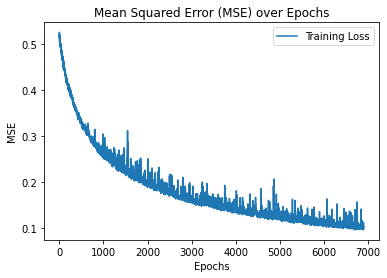

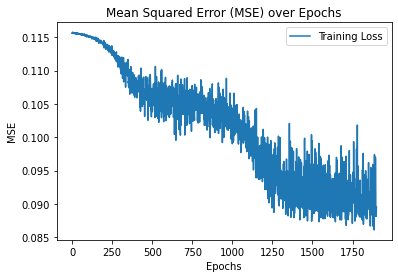

low fidelity NN
Test MSE: 0.013298082781637523
R^2: 0.8932998689065464
Final model
Test MSE: 0.08909216080307521
R^2: 0.21295834374128508


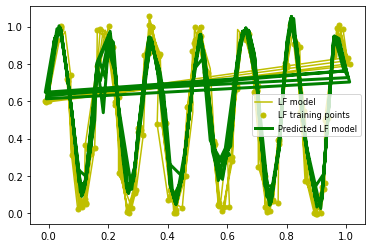

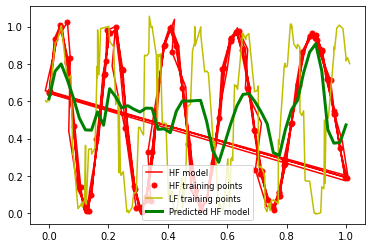

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_6260\1919213603.py:174: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df = r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_6260\1919213603.py:176: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df = r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_6260\1919213603.py:178: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df = mse_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_6260\1919213603.py:180: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_HF_df = mse_HF_df.app

********************  # Nb. nodes = 28  ********************
********************  # Diff: = 5  ********************
********************  # NHF: = 100  ********************
********************  # NLF: = 200  ********************


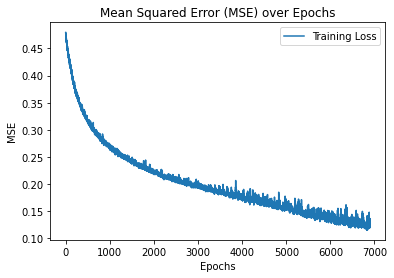

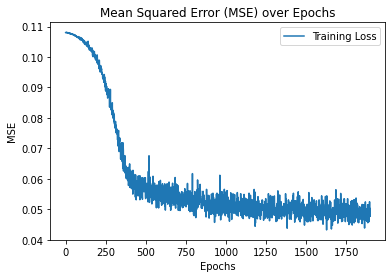

low fidelity NN
Test MSE: 0.03377679001570229
R^2: 0.7017698558233683
Final model
Test MSE: 0.03307135501559513
R^2: 0.7078470901191172


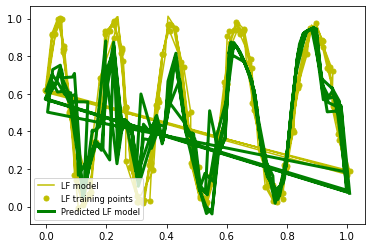

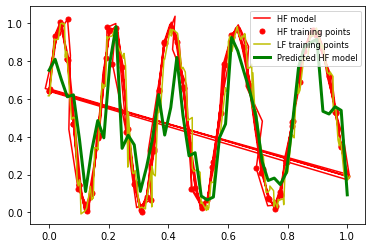

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_6260\1919213603.py:174: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df = r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_6260\1919213603.py:176: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df = r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_6260\1919213603.py:178: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df = mse_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_6260\1919213603.py:180: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_HF_df = mse_HF_df.app

********************  # Nb. nodes = 28  ********************
********************  # Diff: = 75  ********************
********************  # NHF: = 100  ********************
********************  # NLF: = 200  ********************


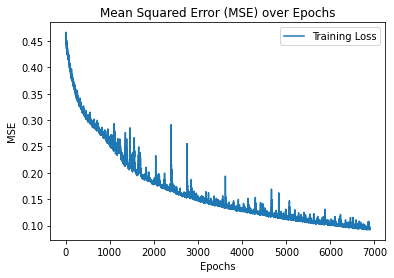

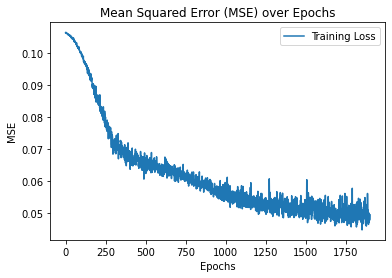

low fidelity NN
Test MSE: 0.0037990781236449246
R^2: 0.9676885062476932
Final model
Test MSE: 0.0488438650715517
R^2: 0.5685124693634737


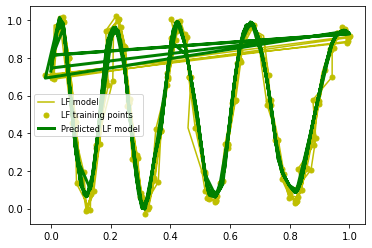

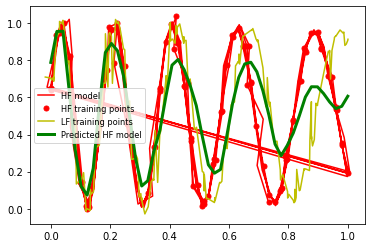

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_6260\1919213603.py:174: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df = r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_6260\1919213603.py:176: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df = r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_6260\1919213603.py:178: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df = mse_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_6260\1919213603.py:180: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_HF_df = mse_HF_df.app

********************  # Nb. nodes = 28  ********************
********************  # Diff: = 1  ********************
********************  # NHF: = 100  ********************
********************  # NLF: = 200  ********************


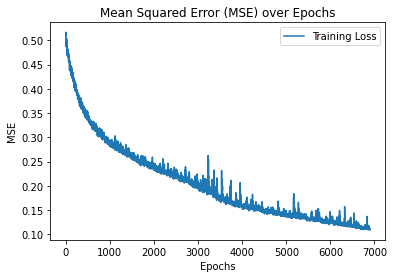

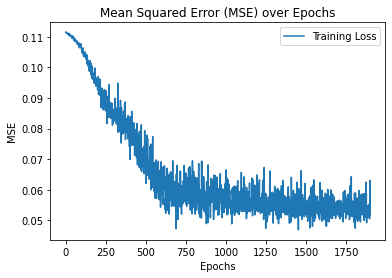

low fidelity NN
Test MSE: 0.003480297470664435
R^2: 0.9705673468925544
Final model
Test MSE: 0.061253076821434924
R^2: 0.4588892827614479


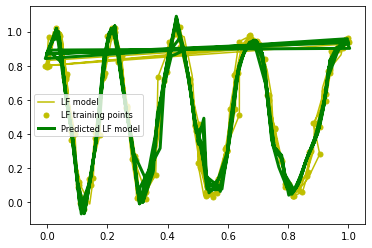

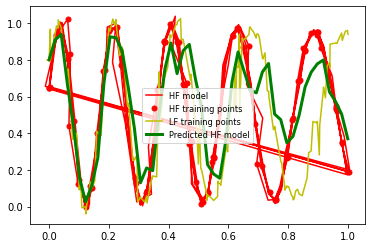

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_6260\1919213603.py:174: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df = r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_6260\1919213603.py:176: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df = r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_6260\1919213603.py:178: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df = mse_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_6260\1919213603.py:180: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_HF_df = mse_HF_df.app

********************  # Nb. nodes = 10  ********************
********************  # Diff: = 0  ********************
********************  # NHF: = 100  ********************
********************  # NLF: = 200  ********************


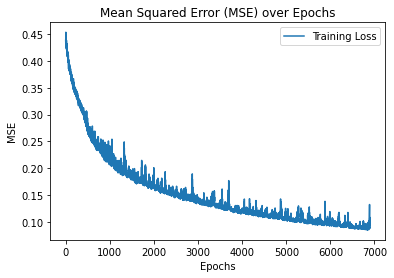

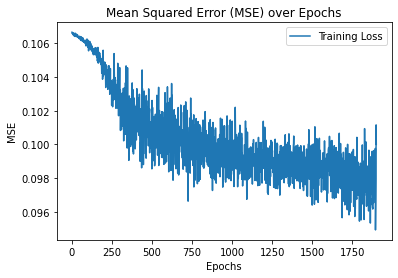

low fidelity NN
Test MSE: 0.009959971290449298
R^2: 0.9201100046114536
Final model
Test MSE: 0.1035291400670937
R^2: 0.08542182460307568


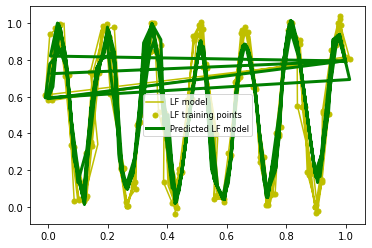

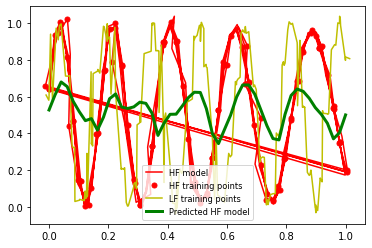

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_6260\1919213603.py:174: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df = r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_6260\1919213603.py:176: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df = r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_6260\1919213603.py:178: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df = mse_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_6260\1919213603.py:180: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_HF_df = mse_HF_df.app

********************  # Nb. nodes = 10  ********************
********************  # Diff: = 5  ********************
********************  # NHF: = 100  ********************
********************  # NLF: = 200  ********************


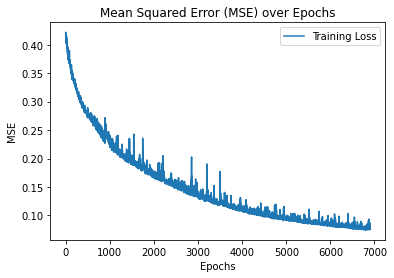

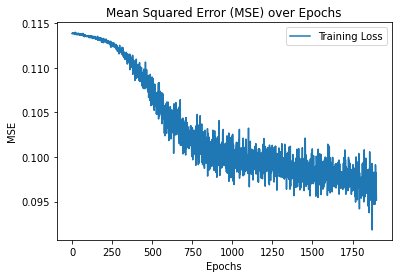

low fidelity NN
Test MSE: 0.006290207535069339
R^2: 0.9494403297842552
Final model
Test MSE: 0.10092071977869889
R^2: 0.10846465357357049


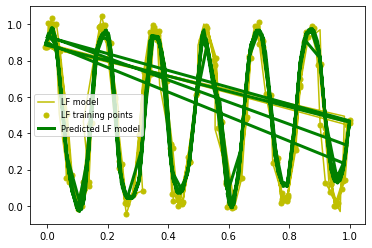

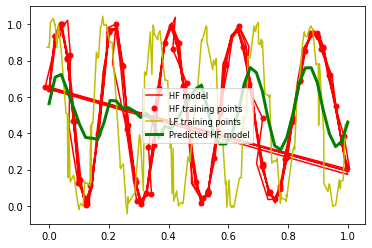

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_6260\1919213603.py:174: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df = r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_6260\1919213603.py:176: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df = r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_6260\1919213603.py:178: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df = mse_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_6260\1919213603.py:180: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_HF_df = mse_HF_df.app

********************  # Nb. nodes = 10  ********************
********************  # Diff: = 75  ********************
********************  # NHF: = 100  ********************
********************  # NLF: = 200  ********************


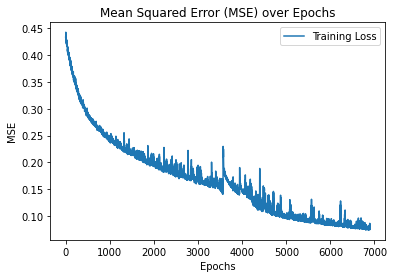

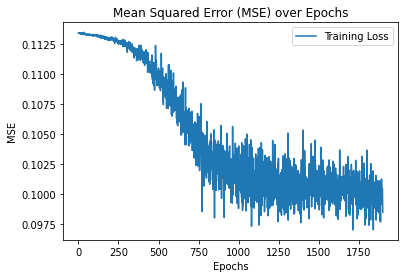

low fidelity NN
Test MSE: 0.010188687049752366
R^2: 0.9201349292421344
Final model
Test MSE: 0.10307591326027697
R^2: 0.08942563788454194


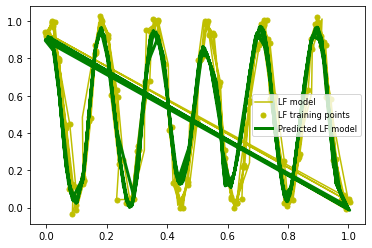

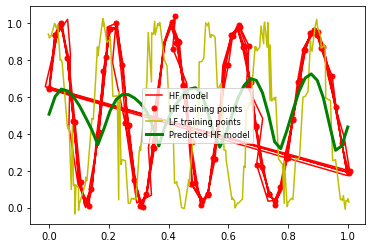

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_6260\1919213603.py:174: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df = r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_6260\1919213603.py:176: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df = r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_6260\1919213603.py:178: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df = mse_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_6260\1919213603.py:180: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_HF_df = mse_HF_df.app

********************  # Nb. nodes = 10  ********************
********************  # Diff: = 1  ********************
********************  # NHF: = 100  ********************
********************  # NLF: = 200  ********************


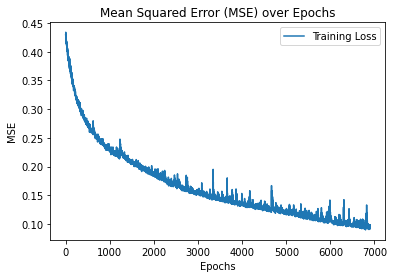

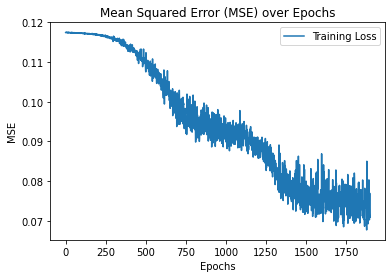

low fidelity NN
Test MSE: 0.006878266610389752
R^2: 0.9433856835704036
Final model
Test MSE: 0.06902931145190155
R^2: 0.39019389443714114


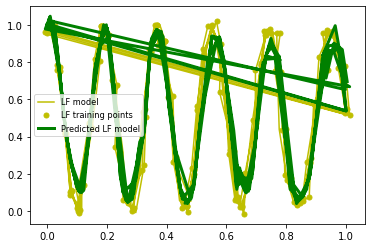

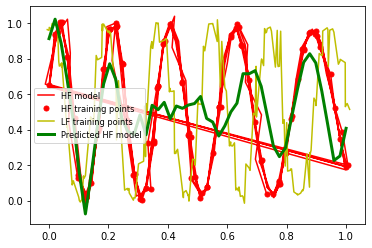

    Discretization  diffusion       R2
0             46.0        0.0  0.02541
1             46.0        5.0  0.79081
2             46.0       75.0  0.88094
3             46.0        1.0  0.86341
4             28.0        0.0  0.21296
5             28.0        5.0  0.70785
6             28.0       75.0  0.56851
7             28.0        1.0  0.45889
8             10.0        0.0  0.08542
9             10.0        5.0  0.10846
10            10.0       75.0  0.08943
11            10.0        1.0  0.39019
    Discretization  diffusion      MSE
0             46.0        0.0  0.11032
1             46.0        5.0  0.02368
2             46.0       75.0  0.01348
3             46.0        1.0  0.01546
4             28.0        0.0  0.08909
5             28.0        5.0  0.03307
6             28.0       75.0  0.04884
7             28.0        1.0  0.06125
8             10.0        0.0  0.10353
9             10.0        5.0  0.10092
10            10.0       75.0  0.10308
11            10.0       

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_6260\1919213603.py:174: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df = r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_6260\1919213603.py:176: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df = r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_6260\1919213603.py:178: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df = mse_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_6260\1919213603.py:180: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_HF_df = mse_HF_df.app

In [9]:
 test_mse_HF_list = []
test_mse_LF_list = []

r2_HF_list = []
r2_LF_list = []

for m in range(len(Discretizations)):
    for d in range(len(diffusion)):
        for nhf in n_HF:
            for nlf in Nlf:
                permutation = np.random.permutation(len(reaction_HF_test))
                ### IMPORT LF DATASETs
                file_path_LF = "../DATA/reaction_diffusion_LF_"+str(Discretizations[m])+"_d"+str(diffusion[d])+".mat"
                (reaction_LF_test, U_LF_test) = import_data(file_path_LF)
                reaction_HF = reaction_HF_test[permutation,:][0:nhf,:]
                U_HF = U_HF_test[permutation][0:nhf]
                #print(nhf)

                
                reaction_LF_test = normalization(reaction_LF_test)
                U_LF_test = U_LF_test[
                :,
                - 1,
                int(4*(Discretizations[m]-1)/9),
                int(4*(Discretizations[m]-1)/9)
                ]        
                U_LF_test = normalization(U_LF_test)
                
                reaction_LF_test_original=np.c_[reaction_LF_test, np.abs(np.sin(5*np.pi*reaction_LF_test[:, 0]-5*np.pi/6))]
                U_LF_test_original=U_LF_test
                
                # NOISE
                noise_std1=[0.02,0.01,0.02,0.01]
                noise_std2=[0.01,0.005,0.01,0.005]

                (U_LF_test,reaction_LF_test)=add_noise(noise_std1,noise_std2,reaction_LF_test,U_LF_test)
                
                # randomization
                permutation = np.random.permutation(len(reaction_LF_test))
                reaction_LF = reaction_LF_test[permutation][0:nlf]
                U_train_LF = U_LF_test[permutation][0:nlf]

                reaction_LF=np.c_[reaction_LF, np.abs(np.sin(5*np.pi*reaction_LF[:, 0]-5*np.pi/6))]
                reaction_LF_test=np.c_[reaction_LF_test, np.abs(np.sin(5*np.pi*reaction_LF_test[:, 0]-5*np.pi/6))]
                
                
                print(
                f"********************  # Nb. nodes = {Discretizations[m]}  ********************"
                )
                
                print(
                f"********************  # Diff: = {diffusion[d]}  ********************"
                )
                
                print(
                f"********************  # NHF: = {nhf}  ********************"
                )
                print(
                f"********************  # NLF: = {nlf}  ********************"
                )

               
                
                ##########################       FIRST NN: NN_LF     ##########################
                K.clear_session()
                bestLF_params = {
                    "lr": 0.0255,
                    "kernel_init": "glorot_uniform",
                    "opt": "Adam",
                } 
                best_params={'kernel_init': 'uniform', 'l2weight': 0.005395541657336886, 'lr': 0.0025412188591473228, 'nodes': 12.0, 'opt': 'Adamax'}

                # reproducibilty porpuse 
                learning_rate = bestLF_params["lr"]
                optimizer_type = bestLF_params["opt"]

                # Fissa i parametri di ottimizzazione
                if optimizer_type == "Adam":
                    optimizer = Adam(learning_rate=learning_rate, beta_1=0.9, beta_2=0.999, epsilon=1e-7)
                elif optimizer_type == "Nadam":
                    optimizer = Nadam(learning_rate=learning_rate, beta_1=0.9, beta_2=0.999, epsilon=1e-7)
                elif optimizer_type == "Adamax":
                    optimizer = Adamax(learning_rate=learning_rate, beta_1=0.9, beta_2=0.999, epsilon=1e-7)
                else:
                    raise ValueError(f"Optimizer type '{optimizer_type}' not recognized.")
                #
                names=["LF","2step"]
                params=[bestLF_params, best_params]
                model= MultiFidelity(names,params=params,data_train_LF=reaction_LF,output_train_LF=U_train_LF,data_train_HF=reaction_HF, output_train_HF=U_HF,N=Nepo,n=batch_size,do_HPO=False,verbose=False)


                ULF = model.model_list[0].prediction(reaction_LF_test_original)

                # U_LF_list.append(ULF)
                # print("\nLF Model:")
                print("low fidelity NN")
                (test_mse_LF,r2_LF) = model.model_list[0].performance(reaction_LF_test_original,U_LF_test_original)
                test_mse_LF_list.append(test_mse_LF)

                r2_LF_list.append(r2_LF)

                input_HF = np.concatenate(
                    (reaction_HF_test_original,  model.model_list[0].prediction(reaction_HF_test_original).reshape(-1,1)),axis=1
                )  # <- TRAINING INPUT for the second NN: NN_HF

                input_HF_train = np.concatenate(
                    (reaction_HF,  model.model_list[0].prediction(reaction_HF).reshape(-1,1)),axis=1
                ) 

                print("Final model")
                (test_mse_HF,r2_HF) = model.model_list[1].performance(input_HF,U_HF_test_original)

                
                test_mse_HF_list.append(test_mse_HF)

                r2_HF_list.append(r2_HF)
                #print(f"R^2: {r2_HF}")
                
                
                plt.figure()
                plt.plot(
                reaction_LF_test[:, 0], U_LF_test, "y-", linewidth=1.5, label="LF model"
                )
                plt.plot(
                reaction_LF[:, 0],
                U_train_LF,
                "yo",
                markersize=5,
                label="LF training points",
                )
                plt.plot(
                reaction_LF_test[:, 0],
                model.model_list[0].prediction(reaction_LF_test),
                "g-",
                linewidth=3,
                label="Predicted LF model",
                )
                plt.legend(prop={"size": 8.3})
                plt.show()
                
                plt.figure()
                plt.plot(
                reaction_HF_test[:,0], U_HF_test, "r-", linewidth=1.5, label="HF model"
                )
                plt.plot(
                input_HF_train[:, 0],
                U_HF,
                "ro",
                markersize=5,
                label="HF training points",
                )
                
                
                order=np.argsort(reaction_LF[:,0])
                
                plt.plot(
                reaction_LF[order,0],
                U_train_LF[order],
                "y-",
                markersize=5,
                label="LF training points",
                )
                plt.plot(
                input_HF[:, 0],
                model.model_list[1].prediction(input_HF),
                "g-",
                linewidth=3,
                label="Predicted HF model",
                )
                plt.legend(prop={"size": 8.3})
                plt.show()
                
                new = {'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'R2': r2_LF_list[-1]}
                r2_LF_df = r2_LF_df.append(new, ignore_index=True)      
                new = {'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'R2': r2_HF_list[-1]}
                r2_HF_df = r2_HF_df.append(new, ignore_index=True)  
                new = {'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'MSE': test_mse_LF_list[-1]}
                mse_LF_df = mse_LF_df.append(new, ignore_index=True) 
                new = {'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'MSE': test_mse_HF_list[-1]}
                mse_HF_df = mse_HF_df.append(new, ignore_index=True)
                 
                ##  SALVATAGGIO CON NUOVA CLASSE?
                
                if  len(r2_HF_list)==1:
                    print("SAVING...")
                    model.save
                elif r2_HF_list[-1]==max(r2_HF_list) and test_mse_HF_list[-1]==np.min(test_mse_HF_list):
                    print("SAVING...")
                    model.save
        
print(r2_HF_df.round(5))
print(mse_HF_df.round(5))



## Save the output

In [12]:
os.makedirs("MF_LF_200_7000_HF_100_8000_2NN_noise_fourier_class")

r2_HF_df.to_csv(
    "./MF_LF_200_7000_HF_100_8000_2NN_noise_fourier_class/r2_HF_lhs.txt",
    header=True,
    index=False,
    sep="\t",
    mode="a",
)
mse_HF_df.to_csv(
    "./MF_LF_200_7000_HF_100_8000_2NN_noise_fourier_class/mse_HF_lhs.txt",
    header=True,
    index=False,
    sep="\t",
    mode="a",
)
r2_LF_df.to_csv(
    "./MF_LF_200_7000_HF_100_8000_2NN_noise_fourier_class/r2_LF_lhs.txt",
    header=True,
    index=False,
    sep="\t",
    mode="a",
)
mse_LF_df.to_csv(
    "./MF_LF_200_7000_HF_100_8000_2NN_noise_fourier_class/mse_LF_lhs.txt",
    header=True,
    index=False,
    sep="\t",
    mode="a",
)

with open("./MF_LF_200_7000_HF_100_8000_2NN_noise_fourier_class/U_HF_list.data", "wb") as filehandle:
    # store the data as binary data stream
    pickle.dump(U_HF_list, filehandle)

with open("./MF_LF_200_7000_HF_100_8000_2NN_noise_fourier_class/U_LF_list.data", "wb") as filehandle:
    pickle.dump(U_LF_list, filehandle)

FileExistsError: [WinError 183] Impossibile creare un file, se il file esiste già: 'MF_LF_200_7000_HF_100_8000_2NN_noise_fourier_class'